In [ ]:
!pip install torch

Transformers for using BERT(Bidirectional Encoder Representations from Transformers)



In [ ]:
!pip install transformers

Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd

#data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification,AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

#to avoid warnings
import warnings
warnings.filterwarnings('ignore')

In [31]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


Load the datasets

In [2]:
data = pd.read_csv(r"/content/train.csv", engine='python') #The Python engine manages unclosed quotes and malformed lines
print(data.head())

                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


Data Visualization to Understand Class Distribution

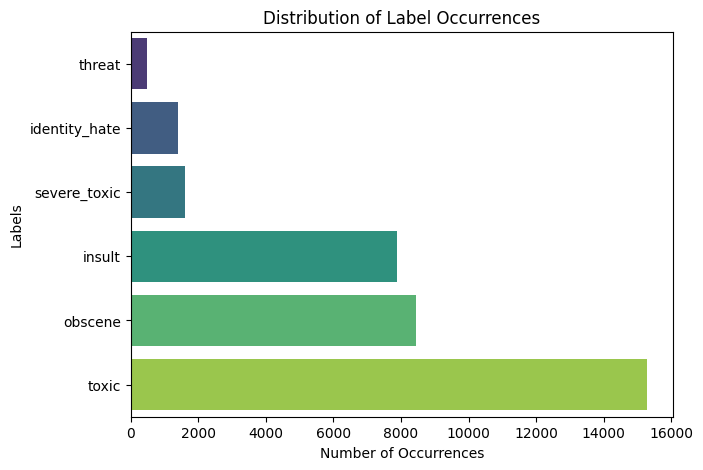

In [3]:
# Visualizing the class distribution of the 'label' column
column_labels = data.columns.tolist()[2:]
label_counts = data[column_labels].sum().sort_values()


# Create a black background for the plot
plt.figure(figsize=(7, 5))

# Create a horizontal bar plot using Seaborn
ax = sns.barplot(x=label_counts.values,
                 y=label_counts.index, palette='viridis')


# Add labels and title to the plot
plt.xlabel('Number of Occurrences')
plt.ylabel('Labels')
plt.title('Distribution of Label Occurrences')

# Show the plot
plt.show()

Checking exact values for each class

In [4]:
data[column_labels].sum().sort_values()


,0
threat,478
identity_hate,1405
severe_toxic,1595
insult,7877
obscene,8449
toxic,15294


**Toxic and Non-Toxic Data**

Let's check if the data is balanced or not by comparing toxic and clean comments by creating their subsets, and then create a new data frame to visualize and gain insights on the distribution of the dataset.

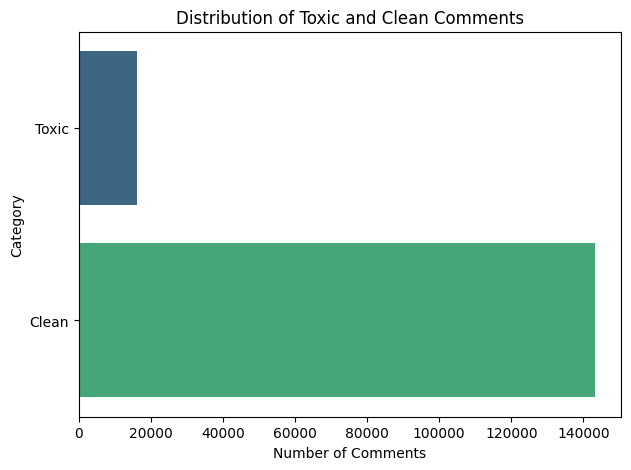

In [5]:
# Create subsets based on toxic and clean comments
train_toxic = data[data[column_labels].sum(axis=1) > 0]
train_clean = data[data[column_labels].sum(axis=1) == 0]

# Number of toxic and clean comments
num_toxic = len(train_toxic)
num_clean = len(train_clean)

# Create a DataFrame for visualization
plot_data = pd.DataFrame(
    {'Category': ['Toxic', 'Clean'], 'Count': [num_toxic, num_clean]})

# Create a black background for the plot
plt.figure(figsize=(7, 5))

# Horizontal bar plot
ax = sns.barplot(x='Count', y='Category', data=plot_data, palette='viridis')


# Add labels and title to the plot
plt.xlabel('Number of Comments')
plt.ylabel('Category')
plt.title('Distribution of Toxic and Clean Comments')

# Set ticks' color to white
ax.tick_params()

# Show the plot
plt.show()

We can observe that our dataset is severely imbalanced.

Let's have a look at the proportion of toxic and clean comments in numbers in order to know the exact numbers and balance the data accordingly.

In [6]:
print(train_toxic.shape)
print(train_clean.shape)

(16225, 8)
(143346, 8)


There is a huge difference in the dataset between toxic and clean comments.

**Handling class imbalance**

To handle the imbalanced data, we can create a new training set in which the number of toxic comments remains the same, and to match that, we will randomly sample 16,225 clean comments and include them in the training set.

The new balanced data frame

In [7]:
# Randomly sample 15,000 clean comments
train_clean_sampled = train_clean.sample(n=16225, random_state=42)

# Combine the toxic and sampled clean comments
dataframe = pd.concat([train_toxic, train_clean_sampled], axis=0)

# Shuffle the data to avoid any order bias during training
dataframe = dataframe.sample(frac=1, random_state=42)

In [8]:
# let's verify with actual figures
print(train_toxic.shape)
print(train_clean_sampled.shape)
print(dataframe.shape)

(16225, 8)
(16225, 8)
(32450, 8)


Now, the dataset is balanced with exactly equal instances of toxic and clean comments we can proceed further to tokenizing and encoding comments using BertTokenizer.

**Split Data into Training, Validation, and Testing Sets**

In this step, we split the data into training, validation, and testing sets. The data is divided into training and testing sets first, and then the testing set is further split into validation and testing sets.

In [9]:
# Split data into training, testing sets & validation sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    dataframe['comment_text'], dataframe.iloc[:, 2:], test_size=0.25, random_state=42)

Now, we split the validation set

In [10]:
# validation set
test_texts, val_texts, test_labels, val_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42)

Now, we will tokenize and encode the comments and labels for the training, testing, and validation sets.



**Tokenization and Encoding**

Defining 'tokenize_and_encode' function to perform this task

In [11]:
# Token and Encode Function
def tokenize_and_encode(tokenizer, comments, labels, max_length=128):
    # Initialize empty lists to store tokenized inputs and attention masks
    input_ids = []
    attention_masks = []

    # Iterate through each comment in the 'comments' list
    #for comment in comments:

        # Tokenize and encode the comment using the BERT tokenizer
    encoded_dict = tokenizer(
            #list(comment),
            comments.tolist(),

            # Add special tokens like [CLS] and [SEP]
            add_special_tokens=True,

            # Truncate or pad the comment to 'max_length'
            max_length=max_length,

            # Pad the comment to 'max_length' with zeros if needed
            pad_to_max_length=True,

            # Return attention mask to mask padded tokens
            return_attention_mask=True,

            padding='max_length',
            truncation=True,

            # Return PyTorch tensors
            return_tensors='pt'
          )

        # Append the tokenized input and attention mask to their respective lists
        #input_ids.append(encoded_dict['input_ids'])
        #attention_masks.append(encoded_dict['attention_mask'])


    # Concatenate the tokenized inputs and attention masks into tensors
    #input_ids = torch.cat(input_ids, dim=0)
    #attention_masks = torch.cat(attention_masks, dim=0)

    input_ids = encoded_dict['input_ids']
    attention_masks = encoded_dict['attention_mask']

    # Convert the labels to a PyTorch tensor with the data type float32
    labels = torch.tensor(labels, dtype=torch.float32)

    # Return the tokenized inputs, attention masks, and labels as PyTorch tensors
    return input_ids, attention_masks, labels

**Initialize Tokenizer and Model**

Now, we will Initialize the BERT tokenizer with the 'bert-base-uncased' model

In [12]:
# Token Initialization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased',do_lower_case=True)
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**Initialize BERT classification Model**

After this step, we will initialize the BERT model for sequence classification

In [13]:
# Model Initialization
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=6)

# Save the model so it loads instantly next time
model.save_pretrained("./my-saved-model")

# Next time just load saved folder
# model = BertForSequenceClassification.from_pretrained("./my-saved-model")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Now, an additional step for faster processing of the model. You can move the model to the GPU if available, or to the CPU if not.

In [14]:
# Move model to GPU if available
device = torch.device(
    'cuda') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)

**Apply Tokenization and Encoding**

Tokenize and Encode the comments and labels of the train, test and validation set

In [15]:
# Tokenize and Encode the comments and labels for the training set
input_ids, attention_masks, labels = tokenize_and_encode(tokenizer,train_texts,train_labels.values)

# Tokenize and Encode the comments and labels for the test set
test_input_ids, test_attention_masks, test_labels = tokenize_and_encode(tokenizer,test_texts,test_labels.values)

# Tokenize and Encode the comments and labels for the validation set
val_input_ids, val_attention_masks, val_labels = tokenize_and_encode(
    tokenizer,
    val_texts,
    val_labels.values
)


print('Training Comments :',train_texts.shape)
print('Input Ids         :',input_ids.shape)
print('Attention Mask    :',attention_masks.shape)
print('Labels            :',labels.shape)

Training Comments : (24337,)
Input Ids         : torch.Size([24337, 128])
Attention Mask    : torch.Size([24337, 128])
Labels            : torch.Size([24337, 6])


Let's check an encoded text with the corresponding text and labels

In [16]:
k = 53
print('Training Comments -->>',train_texts.values[k])
print('\nInput Ids -->>\n',input_ids[k])
print('\nDecoded Ids -->>\n',tokenizer.decode(input_ids[k]))
print('\nAttention Mask -->>\n',attention_masks[k])
print('\nLabels -->>',labels[k])

Training Comments -->> They did and have done, on my talk page and on their talk page and most the time im not really doing anything and i always seem to get the finger pointed at me. So what do you expect me to do if someone is uncivil towards me?

Input Ids -->>
 tensor([  101,  2027,  2106,  1998,  2031,  2589,  1010,  2006,  2026,  2831,
         3931,  1998,  2006,  2037,  2831,  3931,  1998,  2087,  1996,  2051,
        10047,  2025,  2428,  2725,  2505,  1998,  1045,  2467,  4025,  2000,
         2131,  1996,  4344,  4197,  2012,  2033,  1012,  2061,  2054,  2079,
         2017,  5987,  2033,  2000,  2079,  2065,  2619,  2003,  4895,  6895,
        14762,  2875,  2033,  1029,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,    

**Creating Pytorch Data Loaders**

Now, we will create data loaders to efficiently load the data during training, testing, and validation. The data loaders batch the input data and handle shuffling for the training data.

In [17]:
# Creating DataLoader for the balanced dataset
batch_size = 32
train_dataset = TensorDataset(input_ids, attention_masks, labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# testing set
test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# validation set
val_dataset = TensorDataset(val_input_ids, val_attention_masks, val_labels)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Let's check the train_loader data

In [18]:
print('Batch Size :',train_loader.batch_size)
Batch =next(iter(train_loader))
print('Each Input ids shape :',Batch[0].shape)
print('Input ids :\n',Batch[0][0])
print('Corresponding Decoded text:\n',tokenizer.decode(Batch[0][0]))
print('Corresponding Attention Mask :\n',Batch[1][0])
print('Corresponding Label:',Batch[2][0])

Batch Size : 32
Each Input ids shape : torch.Size([32, 128])
Input ids :
 tensor([  101,  1000,  9152,  6396, 25970,  2094,  1010,  2017,  2165,  2023,
         3247,  2894,  1010,  2302,  5981,  2007,  2060, 25353, 28793,  2015,
         1998,  2017,  2024,  1037, 12130,  1997,  3644, 11377,  1006,  1996,
         2592,  2003,  2590,  2438,  2012,  2115,  2159,  2000,  2008,  2017,
         5254,  2023,  2006,  2017,  5310,  3931,  1007,  1012,  1998,  6168,
         2006,  1996,  2019,  1013,  1045,  3931,  2017,  2831,  2055,  1000,
         1000,  2936,  3796,  1000,  1000,  2182,  2017, 17016,  2033,  1997,
         1000,  1000, 25617,  3796,  1000,  1000,  1012,  1000,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     

In [23]:
# Optimizer setup
optimizer = AdamW(model.parameters(), lr=2e-5)

**Model Training**

In [24]:
# Function to Train the Model
def train_model(model, train_loader, optimizer, device, num_epochs):
    # Loop through the specified number of epochs
    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()
        # Initialize total loss for the current epoch
        total_loss = 0

        # Loop through the batches in the training data
        for batch in train_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            optimizer.zero_grad()

            outputs = model(
                input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()  # Set the model to evaluation mode
        val_loss = 0

        # Disable gradient computation during validation
        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, labels = [
                    t.to(device) for t in batch]

                outputs = model(
                    input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                val_loss += loss.item()
        # Print the average loss for the current epoch
        print(
            f'Epoch {epoch+1}, Training Loss: {total_loss/len(train_loader)},Validation loss:{val_loss/len(val_loader)}')


# Call the function to train the model
train_model(model, train_loader, optimizer, device, num_epochs=3)

Epoch 1, Training Loss: 0.2009112446051233,Validation loss:0.15321006444026167
Epoch 2, Training Loss: 0.13854476378229538,Validation loss:0.1495338397936558
Epoch 3, Training Loss: 0.11473615270759054,Validation loss:0.15546608769048856


**Model Evaluation**

In [25]:
# Evaluate the Model
def evaluate_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode

    true_labels = []
    predicted_probs = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            # Get model's predictions
            outputs = model(input_ids, attention_mask=attention_mask)
            # Use sigmoid for multilabel classification
            predicted_probs_batch = torch.sigmoid(outputs.logits)
            predicted_probs.append(predicted_probs_batch.cpu().numpy())

            true_labels_batch = labels.cpu().numpy()
            true_labels.append(true_labels_batch)

    # Combine predictions and labels for evaluation
    true_labels = np.concatenate(true_labels, axis=0)
    predicted_probs = np.concatenate(predicted_probs, axis=0)
    predicted_labels = (predicted_probs > 0.5).astype(
        int)  # Apply threshold for binary classification

    # Calculate evaluation metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')

    # Print the evaluation metrics
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')


# Call the function to evaluate the model on the test data
evaluate_model(model, test_loader, device)

Accuracy: 0.7172
Precision: 0.8071
Recall: 0.8696


**Save the Model**

In [26]:
# Save the tokenizer and model in the same directory
output_dir = "Saved_model"
# Save model's state dictionary and configuration
model.save_pretrained(output_dir)
# Save tokenizer's configuration and vocabulary
tokenizer.save_pretrained(output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('Saved_model/tokenizer_config.json', 'Saved_model/tokenizer.json')

**Load the Model**


In [27]:
# Load the tokenizer and model from the saved directory
model_name = "Saved_model"
Bert_Tokenizer = BertTokenizer.from_pretrained(model_name)
Bert_Model = BertForSequenceClassification.from_pretrained(
    model_name).to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

**Prediction**

In [28]:
def predict_user_input(input_text, model=Bert_Model, tokenizer=Bert_Tokenizer, device=device):
    user_input = [input_text]

    user_encodings = tokenizer(
        user_input, truncation=True, padding=True, return_tensors="pt")

    user_dataset = TensorDataset(
        user_encodings['input_ids'], user_encodings['attention_mask'])

    user_loader = DataLoader(user_dataset, batch_size=1, shuffle=False)

    model.eval()
    with torch.no_grad():
        for batch in user_loader:
            input_ids, attention_mask = [t.to(device) for t in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.sigmoid(logits)

    predicted_labels = (predictions.cpu().numpy() > 0.5).astype(int)
    labels_list = ['toxic', 'severe_toxic', 'obscene',
                   'threat', 'insult', 'identity_hate']
    result = dict(zip(labels_list, predicted_labels[0]))
    return result


text = 'Are you insane!'
predict_user_input(input_text=text)

{'toxic': np.int64(1),
 'severe_toxic': np.int64(0),
 'obscene': np.int64(0),
 'threat': np.int64(0),
 'insult': np.int64(0),
 'identity_hate': np.int64(0)}

We can observe that the comment 'Are you insane!' is a toxic comment.

let's check for more inputs

In [29]:
predict_user_input(input_text='How are you?')


{'toxic': np.int64(0),
 'severe_toxic': np.int64(0),
 'obscene': np.int64(0),
 'threat': np.int64(0),
 'insult': np.int64(0),
 'identity_hate': np.int64(0)}

In [30]:
text = "Such an Idiot person"
predict_user_input(model=Bert_Model,
                   tokenizer=Bert_Tokenizer,
                   input_text=text,
                   device=device)

{'toxic': np.int64(1),
 'severe_toxic': np.int64(0),
 'obscene': np.int64(1),
 'threat': np.int64(0),
 'insult': np.int64(1),
 'identity_hate': np.int64(0)}